## Imbalanced Data in Machine Learning

**Definition:**  
Imbalanced data refers to a situation where the distribution of classes in a dataset is not equal. One class (majority) has significantly more samples than the other class(es) (minority).

**Example:**  
Consider a binary classification problem with data from an IIT:

- Total students: 500  
- Placed (Class 1): 450  
- Not Placed (Class 0): 50  

Here, the dataset is imbalanced:

- Majority class: Placement (1)  
- Minority class: Not Placement (0)  

This issue can also occur in multiclass classification problems.

---

## Problems with Imbalanced Data

**1) Bias in Model Learning**  
Machine learning models tend to learn more from the majority class due to its higher frequency. As a result, the model may:

- Ignore patterns from the minority class  
- Perform poorly on minority class predictions  
- Become biased toward the majority class  

**2) Misleading Evaluation Metrics**  
Accuracy can be unreliable for imbalanced datasets.

**Example:**

- Placed: 900  
- Not Placed: 100  

A dummy model that predicts all samples as "Placed" will achieve:


### example 
| CGPA | IQ  | Placement |
| ---- | --- | --------- |
| 5.49 | 89  | 0         |
| 7.15 | 137 | 1         |
| 6.03 | 96  | 0         |
| 5.45 | 138 | 1         |
| 4.24 | 131 | 1         |
| 6.46 | 87  | 0         |
| 4.38 | 75  | 1         |
| 8.92 | 127 | 1         |
| 9.64 | 122 | 0         |
| 3.83 | 59  | 0         |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
RANDOM_STATE = 42
N_SAMPLES = [25, 375]   
CENTERS = [(0, 0), (2, 2)]
CLUSTER_STD = [1.5, 1.5]

In [3]:
def generate_imbalanced_data(n_samples, centers, cluster_std, random_state):
    X, y = make_blobs(
        n_samples=n_samples,
        centers=centers,
        cluster_std=cluster_std,
        random_state=random_state
    )
    return X, y

In [5]:
def plot_data(X, y):
    plt.figure(figsize=(8, 6))
    
    plt.scatter(
        X[y == 0][:, 0], X[y == 0][:, 1],
        label='Class 0 (Minority)',
    )
    
    plt.scatter(
        X[y == 1][:, 0], X[y == 1][:, 1],
        label='Class 1 (Majority)',
    )

    plt.title('Imbalanced Dataset (2D)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

Class distribution: [ 25 375]


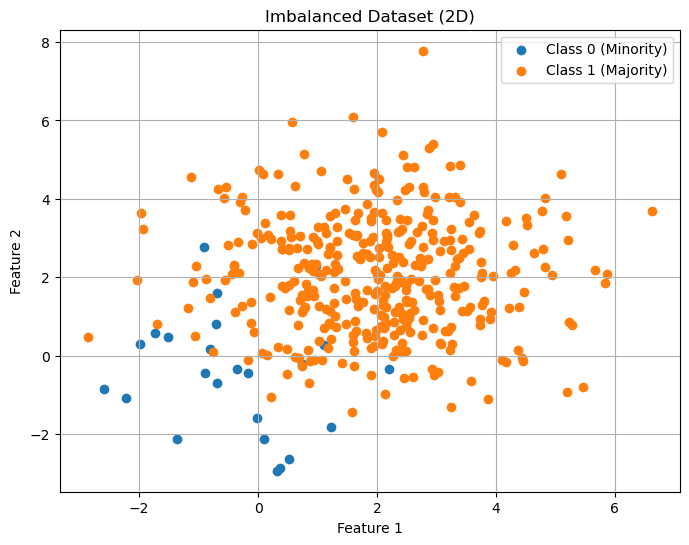

In [6]:
if __name__ == "__main__":
    np.random.seed(RANDOM_STATE)
    
    X, y = generate_imbalanced_data(
        N_SAMPLES, CENTERS, CLUSTER_STD, RANDOM_STATE
    )
    
    print(f"Class distribution: {np.bincount(y)}")
    
    plot_data(X, y)

### training on lr

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


# training and evaluation 
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score: {auc:.4f}")

    return model, y_proba

In [8]:
# ROC curve plot 
def plot_roc_curve(y_test, y_proba):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

In [9]:
# decision boundary plot 
def plot_decision_boundary(X, y, model):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)

    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.98      0.98      0.98       113

    accuracy                           0.97       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.97      0.97      0.97       120

ROC AUC Score: 0.9292


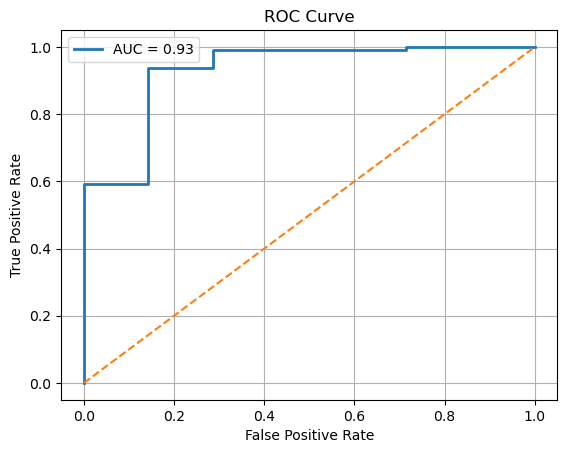

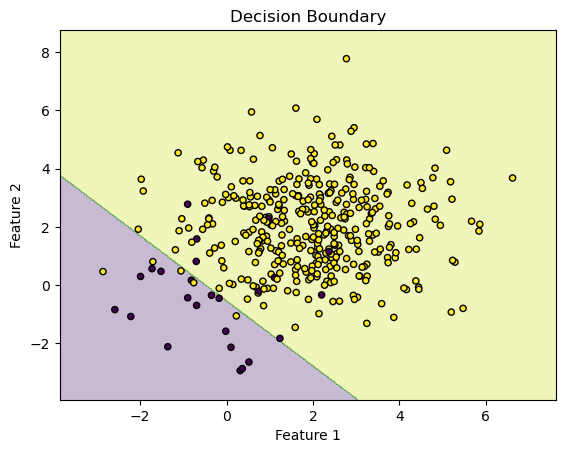

In [10]:
# main execution 
if __name__ == "__main__":
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    model = LogisticRegression()
    model, y_proba = train_and_evaluate(
        model, X_train, X_test, y_train, y_test
    )
    plot_roc_curve(y_test, y_proba)
    plot_decision_boundary(X, y, model)

---------

### why studyng imbalanced data is important ? 

## Importance of Imbalanced Data

**1) Real-World Presence**  
Imbalanced data is very common in real-world machine learning problems:

- **Finance** → Fraud detection, credit risk assessment  
- **Healthcare** → Rare disease detection  
- **Manufacturing** → Machine failure prediction  
- **Consumer Internet** → Churn prediction  
- **Environmental Science** → Natural risk assessment  

In all these cases, the **minority class is the most important**.  
Correctly identifying rare events is critical for decision-making.

---

## Why It Matters

- The cost of misclassifying the minority class is usually **very high**  
- A model with high accuracy can still be **useless in practice**  
- Focus should be on:
  - Recall (minority class)
  - Precision (minority class)
  - F1-score

---

## Interview Perspective

Imbalanced data is a **frequently asked topic** in interviews.

You should be able to clearly explain:

- What is imbalanced data  
- Why accuracy is misleading  
- Which metrics to use instead (Precision, Recall, F1, ROC-AUC)  
- Basic handling techniques:
  - Class weighting
  - Oversampling / Undersampling
  - SMOTE (basic idea)

A strong understanding of this topic reflects **practical ML knowledge**, not just theory.

---
---

# How to handle Imbalance data 



## 1) Undersampling

**Definition:**  
Undersampling is a technique used to handle imbalanced data by reducing the number of samples in the majority class.
## How It Works

- In an imbalanced dataset, the majority class has significantly more samples than the minority class  
- Undersampling randomly selects a subset of the majority class  
- The selected samples are made **equal in number to the minority class**
## Example

- Majority class: 450 samples  
- Minority class: 50 samples  

After undersampling:

- Majority class → reduced to 50 samples  
- Minority class → remains 50 samples  

Result: Balanced dataset (50 : 50)
## Advantages

- Simple and easy to implement  
- Reduces training time  
- Helps model focus equally on both classes  
## Disadvantages

- Loss of important information from the majority class  
- Can lead to underfitting  
- Not ideal when dataset is already small  
##
Undersampling creates balance by **removing data**,  
so it should be used carefully to avoid losing useful patterns.

In [13]:
!pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]



Before Undersampling: Counter({np.int64(1): 299, np.int64(0): 21})
After Undersampling: Counter({np.int64(0): 21, np.int64(1): 21})


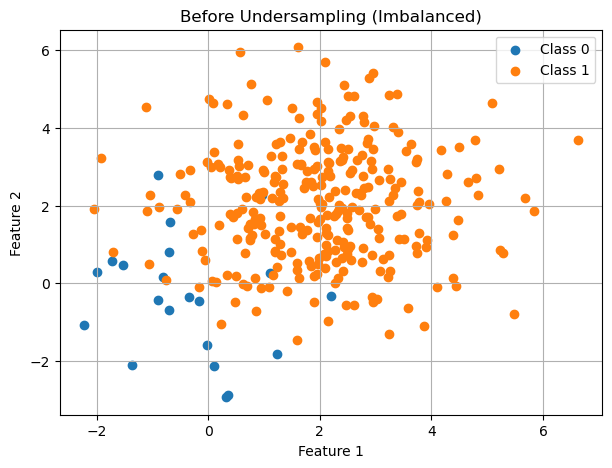

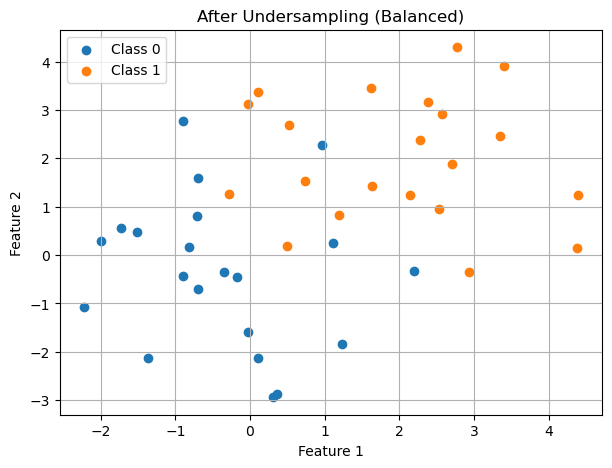

In [14]:
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Plot function
def plot_data(X, y, title):
    plt.figure(figsize=(7, 5))
    
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Before Undersampling:", Counter(y_train))

# applying random undersampling 

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

print("After Undersampling:", Counter(y_resampled))


# visualization
plot_data(X_train, y_train, "Before Undersampling (Imbalanced)")
plot_data(X_resampled, y_resampled, "After Undersampling (Balanced)")

In [16]:
X_train.shape , X_resampled.shape

((320, 2), (42, 2))

In [18]:
import pandas as pd

In [19]:
pd.Series(y_train).value_counts() , pd.Series(y_resampled).value_counts()

(1    299
 0     21
 Name: count, dtype: int64,
 0    21
 1    21
 Name: count, dtype: int64)

Classification Report (With Undersampling):

              precision    recall  f1-score   support

           0       0.23      0.75      0.35         4
           1       0.99      0.87      0.92        76

    accuracy                           0.86        80
   macro avg       0.61      0.81      0.64        80
weighted avg       0.95      0.86      0.89        80

ROC AUC Score (With Undersampling): 0.8717


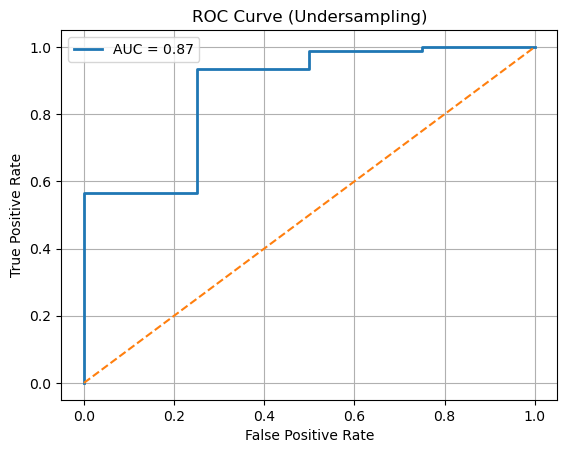

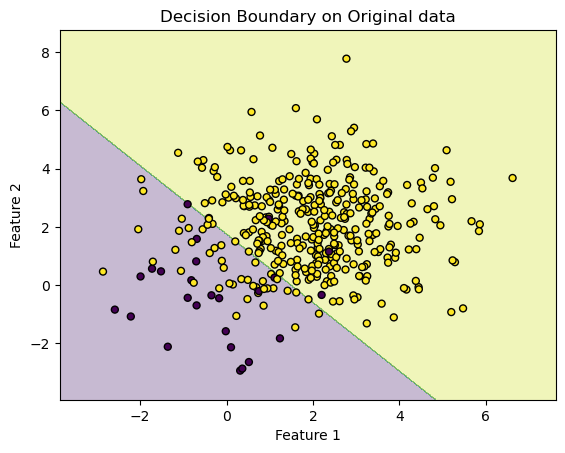

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


# training model on resampled data 
model_rus = LogisticRegression()
model_rus.fit(X_resampled, y_resampled)

# predictions 
y_pred_rus = model_rus.predict(X_test)
y_proba_rus = model_rus.predict_proba(X_test)[:, 1]


# evaluation 

print("Classification Report (With Undersampling):\n")
print(classification_report(y_test, y_pred_rus))

auc_rus = roc_auc_score(y_test, y_proba_rus)
print(f"ROC AUC Score (With Undersampling): {auc_rus:.4f}")

#ROC curve 

def plot_roc(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc(y_test, y_proba_rus, "ROC Curve (Undersampling)")


# decision Boundary 
def plot_decision_boundary(X, y, model, title):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=25)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# plot on original data
plot_decision_boundary(X, y, model_rus, 
                       "Decision Boundary on Original data")

---

# 2) Random Oversampling

**Definition:**  
Random oversampling is a technique used to handle imbalanced data by increasing the number of samples in the minority class.

---

## How It Works

- In an imbalanced dataset, the minority class has fewer samples  
- Random oversampling **duplicates existing minority class samples**  
- This process continues until both classes become balanced  

---

## Example

- Majority class: 450 samples  
- Minority class: 50 samples  

After oversampling:

- Minority class → increased to 450 (by duplication)  
- Majority class → remains 450  

Result: Balanced dataset (450 : 450)

---

## Advantages

- No loss of information (unlike undersampling)  
- Simple to implement  
- Helps improve minority class recall  

---

## Disadvantages

- Can lead to **overfitting** (same data repeated)  
- Does not add new information, only duplicates existing samples  

---
Random oversampling creates balance by **adding duplicate data**,  
which can improve learning but may reduce generalization if overused.

----

In [30]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import matplotlib.pyplot as plt

In [31]:
ros = RandomOverSampler(random_state=42)
X_resampled_ros, y_resampled_ros = ros.fit_resample(X_train, y_train)

print("Before Oversampling:", Counter(y_train))
print("After Oversampling:", Counter(y_resampled_ros))

Before Oversampling: Counter({np.int64(1): 299, np.int64(0): 21})
After Oversampling: Counter({np.int64(1): 299, np.int64(0): 299})


In [32]:
# plot function 
def plot_data(X, y, title):
    plt.figure(figsize=(7, 5))

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

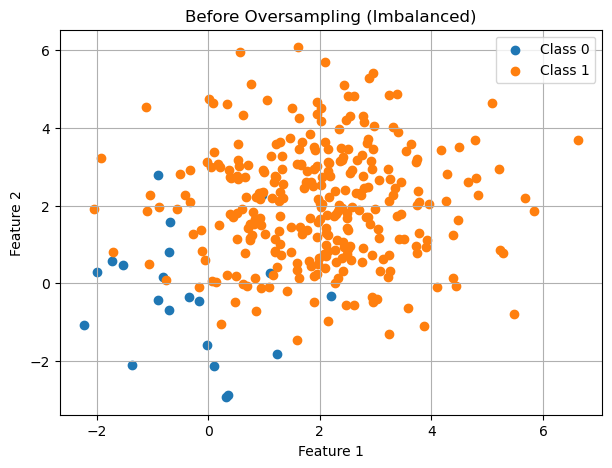

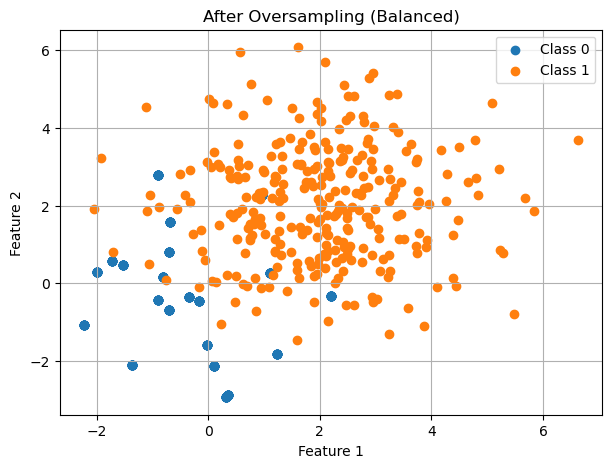

In [33]:
plot_data(X_train, y_train, "Before Oversampling (Imbalanced)")
plot_data(X_resampled_ros, y_resampled_ros, "After Oversampling (Balanced)")

Classification Report (With Oversampling):

              precision    recall  f1-score   support

           0       0.23      0.75      0.35         4
           1       0.99      0.87      0.92        76

    accuracy                           0.86        80
   macro avg       0.61      0.81      0.64        80
weighted avg       0.95      0.86      0.89        80

ROC AUC Score (With Oversampling): 0.8717


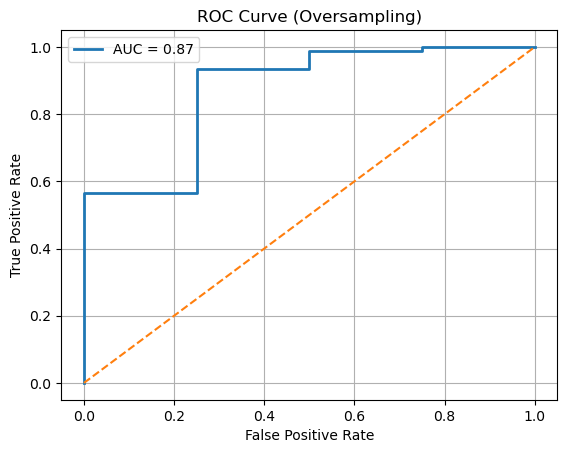

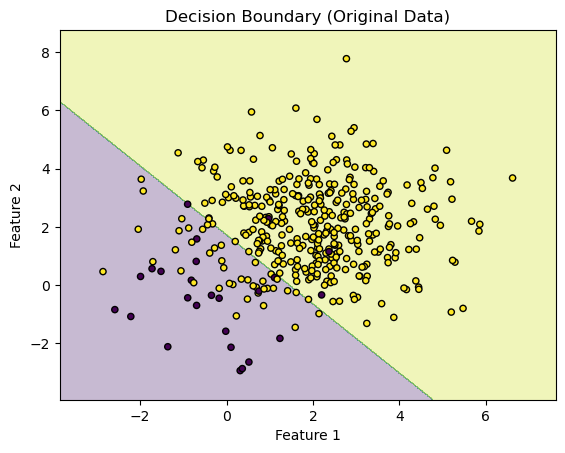

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# training model over oversampled data
model_ros = LogisticRegression()
model_ros.fit(X_resampled_ros, y_resampled_ros)

# predictions

y_pred_ros = model_ros.predict(X_test)
y_proba_ros = model_ros.predict_proba(X_test)[:, 1]


# evaluation 

print("Classification Report (With Oversampling):\n")
print(classification_report(y_test, y_pred_ros))

auc_ros = roc_auc_score(y_test, y_proba_ros)
print(f"ROC AUC Score (With Oversampling): {auc_ros:.4f}")

# ROC curve 
def plot_roc(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc(y_test, y_proba_ros, "ROC Curve (Oversampling)")


# decision boundary 

def plot_decision_boundary(X, y, model, title):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# Plot on oversampled data
plot_decision_boundary(X, y, model_ros,
                       "Decision Boundary (Original Data)")

---
---

# 3) SMOTE (Synthetic Minority Oversampling Technique)

**Definition:**  
SMOTE is an oversampling technique used to handle imbalanced data by generating **new synthetic data points** for the minority class instead of duplicating existing ones.

---

## Idea

- Unlike random oversampling, SMOTE **does not duplicate data**  
- It creates **new samples using interpolation** between existing minority data points  
- This helps reduce **overfitting**

---

## How SMOTE Works

1. Consider only the **minority class data**  
2. Train a **K-Nearest Neighbors (KNN)** model (commonly \( k = 5 \))  
3. For each minority sample, find its **k nearest neighbors**

---

## Synthetic Data Generation

To create a new data point:

- Select a **random minority sample**  
- Select one of its **nearest neighbors**  
- Generate a random number \( \lambda \in [0, 1] \)  
- Create a new point using interpolation:

$$
\text{new sample} = \text{original sample} + \lambda \times (\text{neighbor} - \text{original sample})
$$

---

## Final Dataset

- Original dataset  
- + Newly generated synthetic minority samples  

Result: **Balanced dataset without duplication**

---

## Advantages

- Reduces overfitting compared to random oversampling  
- Introduces new, meaningful data points  
- Improves minority class learning  

---

## Disadvantages

- Can create ambiguous samples (especially near class boundaries)  
- May introduce noise if data is not well separated  

---

## 

SMOTE creates balance by **generating new data points between existing minority samples**,  
making it more effective than simple duplication-based methods.

Before SMOTE: Counter({np.int64(1): 299, np.int64(0): 21})
After SMOTE: Counter({np.int64(1): 299, np.int64(0): 299})


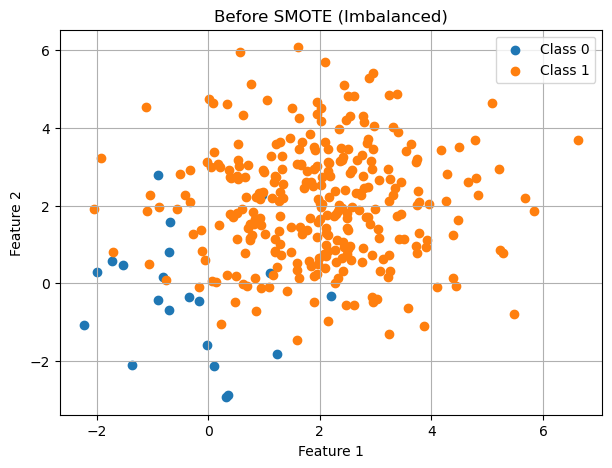

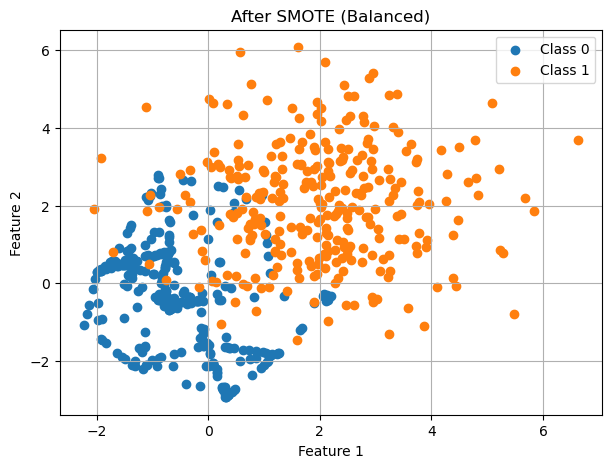

In [39]:
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


# plot function 

def plot_data(X, y, title):
    plt.figure(figsize=(7, 5))

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# train_test_split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Before SMOTE:", Counter(y_train))


# applying SMOTE

smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_resampled_smote))


# Visualization
plot_data(X_train, y_train, "Before SMOTE (Imbalanced)")
plot_data(X_resampled_smote, y_resampled_smote, "After SMOTE (Balanced)")

Classification Report with SMOTE:

              precision    recall  f1-score   support

           0       0.27      0.75      0.40         4
           1       0.99      0.89      0.94        76

    accuracy                           0.89        80
   macro avg       0.63      0.82      0.67        80
weighted avg       0.95      0.89      0.91        80

ROC AUC Score (With SMOTE): 0.8684


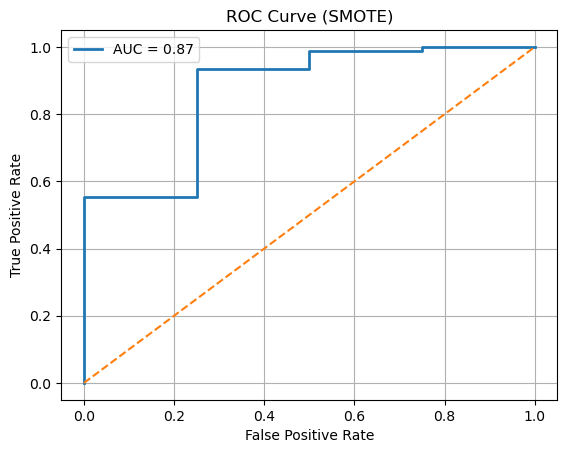

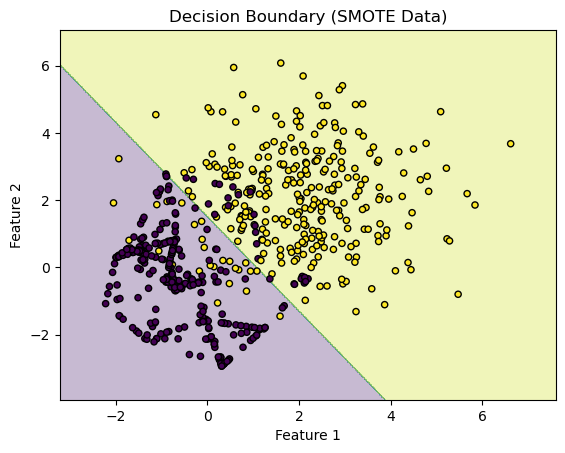

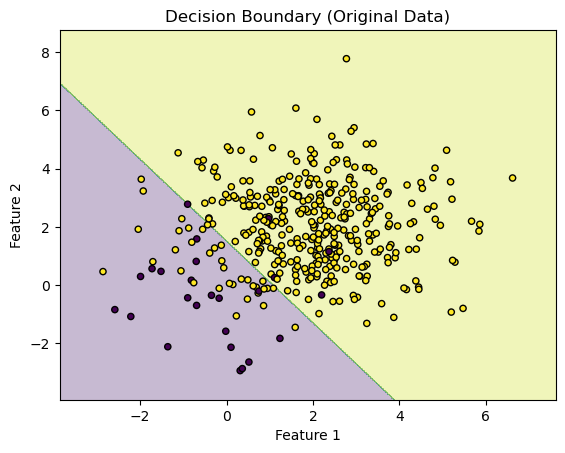

In [41]:
# training model on SMOTE data

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

model_smote = LogisticRegression()
model_smote.fit(X_resampled_smote, y_resampled_smote)

# predictions

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

# Evaluation

print("Classification Report with SMOTE:\n")
print(classification_report(y_test, y_pred_smote))

auc_smote = roc_auc_score(y_test, y_proba_smote)
print(f"ROC AUC Score (With SMOTE): {auc_smote:.4f}")


# ROC curve 

def plot_roc(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc(y_test, y_proba_smote, "ROC Curve (SMOTE)")


# decision boundary

def plot_decision_boundary(X, y, model, title):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# Plot on SMOTE data
plot_decision_boundary(
    X_resampled_smote,
    y_resampled_smote,
    model_smote,
    "Decision Boundary (SMOTE Data)"
)

# Plot on Original data

plot_decision_boundary(
    X,
    y,
    model_smote,
    "Decision Boundary (Original Data)"
)

## Disadvantage in SMOTE

1) Does not handle categorical data
2) Computational complexity 
3) Dependency on the choice of neighour 
4) Sensitive Outlier
5) Balance Achieved may not reflect true nature

----
----

## 4) Ensemble Learning for Imbalanced Data

**Definition:**  
Ensemble learning combines multiple models (typically decision trees) to improve performance.  
For imbalanced data, we can modify ensemble methods to ensure **balanced learning in each model**.

---

## Balanced Random Forest (Idea)

Instead of training on the full imbalanced dataset, we:

- Create multiple **balanced subsets** of data  
- Train a separate **decision tree** on each subset  
- Combine all models using aggregation (e.g., voting)

---

## How It Works

Given:
- Majority class: 900 samples  
- Minority class: 300 samples  

### Step 1: Create Balanced Samples

For each model:
- Take all **300 minority samples**  
- Randomly sample **300 from majority class**  

Now each subset is balanced (300 : 300)

---

### Step 2: Train Multiple Models

- Sample 1 → Train Decision Tree → Model 1  
- Sample 2 → Train Decision Tree → Model 2  
- Sample 3 → Train Decision Tree → Model 3  

Each model sees a **different subset of majority data**

---

### Step 3: Aggregation

- Combine predictions from all models  
- Use **majority voting** (classification)

Final prediction = aggregation of:
- Model 1  
- Model 2  
- Model 3  

---

## Key Advantages

- No data loss of minority class  
- Uses different parts of majority data → better generalization  
- Reduces bias toward majority class  

---

## Disadvantages

- More computationally expensive  
- Still may struggle if classes heavily overlap  

---

## Insight

Balanced Random Forest improves performance by:
- Training each model on **balanced data**
- Using **ensemble aggregation** to capture more patterns from the majority class without bias

---
---

In [42]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

In [43]:
brf = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [44]:
brf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [45]:
y_pred_brf = brf.predict(X_test)
y_proba_brf = brf.predict_proba(X_test)[:, 1]

In [46]:
print("Classification Report (Balanced Random Forest):\n")
print(classification_report(y_test, y_pred_brf))

auc_brf = roc_auc_score(y_test, y_proba_brf)
print(f"ROC AUC Score (Balanced RF): {auc_brf:.4f}")

Classification Report (Balanced Random Forest):

              precision    recall  f1-score   support

           0       0.20      0.75      0.32         4
           1       0.98      0.84      0.91        76

    accuracy                           0.84        80
   macro avg       0.59      0.80      0.61        80
weighted avg       0.95      0.84      0.88        80

ROC AUC Score (Balanced RF): 0.7812


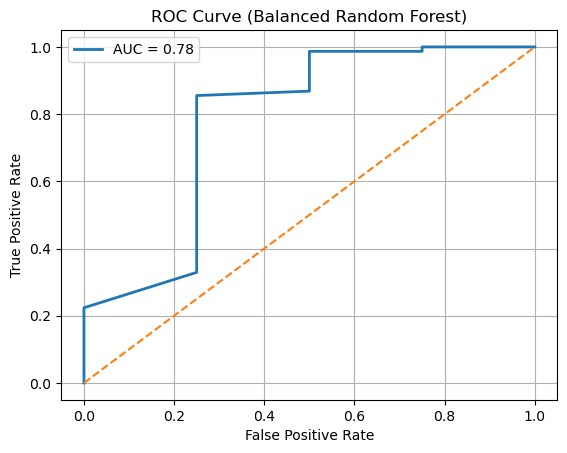

In [47]:
def plot_roc(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc(y_test, y_proba_brf, "ROC Curve (Balanced Random Forest)")

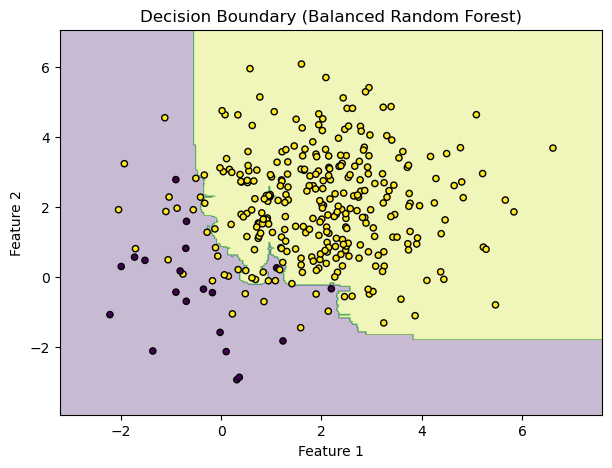

In [48]:
def plot_decision_boundary(X, y, model, title):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(
    X_train, y_train, brf,
    "Decision Boundary (Balanced Random Forest)"
)

| Method          | Recall (0) | Precision (0) | F1 (0)   | Accuracy | AUC  |
| --------------- | ---------- | ------------- | -------- | -------- | ---- |
| Original        | 0.71       | 0.71          | 0.71     | 0.97     | 0.93 |
| Undersampling   | 0.75       | 0.23          | 0.35     | 0.86     | 0.87 |
| Oversampling    | 0.75       | 0.23          | 0.35     | 0.86     | 0.87 |
| **SMOTE**       | 0.75       | **0.27**      | **0.40** | **0.89** | 0.87 |
| **Balanced RF** | 0.75       | 0.20          | 0.32     | 0.84     | 0.78 |


🚨 Most Important Insight :

Not:
> “Which method is best?”

But:

> “Which method fits the data and problem?”

---
---

# 5) Cost-Sensitive Learning

**Definition:**  
Cost-sensitive learning is a technique to handle imbalanced data by assigning **different importance (weights)** to different classes during model training.

---

## Key Idea

- In imbalanced datasets, the minority class is more important  
- We assign **higher weight to the minority class**  
- The model penalizes mistakes on the minority class more heavily  

---

## How It Works

- During training, the model minimizes a **loss function**  
- With class weights, the loss becomes **weighted**

For example:

$$
\text{Weighted Loss} = w_0 \cdot \text{Loss}_0 + w_1 \cdot \text{Loss}_1
$$

Where:
- \( w_0, w_1 \) are class weights  
- Minority class gets **higher weight**

---

## Effect on Learning

- Errors on minority class → **larger penalty**  
- Model updates (e.g., in gradient descent) become:
  - More sensitive to minority class errors  
  - Focus shifts toward learning minority patterns  

---

## In Practice (scikit-learn)

Most ML algorithms that:
- Optimize a loss function  
- Use gradient-based learning  

support a parameter:

```python
class_weight

---
---

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [62]:
model = LogisticRegression(
    class_weight = 'balanced' ,
    solver = 'liblinear'
)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [63]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [64]:
print("Classification Report (Class Weight):\n")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc:.4f}")

Classification Report (Class Weight):

              precision    recall  f1-score   support

           0       0.26      0.86      0.40         7
           1       0.99      0.85      0.91       113

    accuracy                           0.85       120
   macro avg       0.63      0.85      0.66       120
weighted avg       0.95      0.85      0.88       120

ROC AUC Score: 0.9254


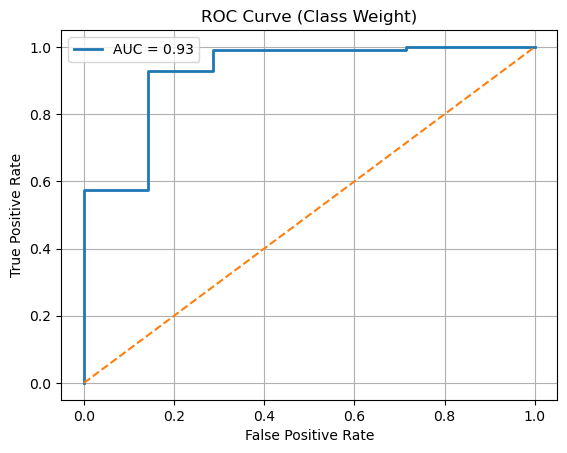

In [65]:
def plot_roc(y_test, y_proba, title):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc(y_test, y_proba, "ROC Curve (Class Weight)")

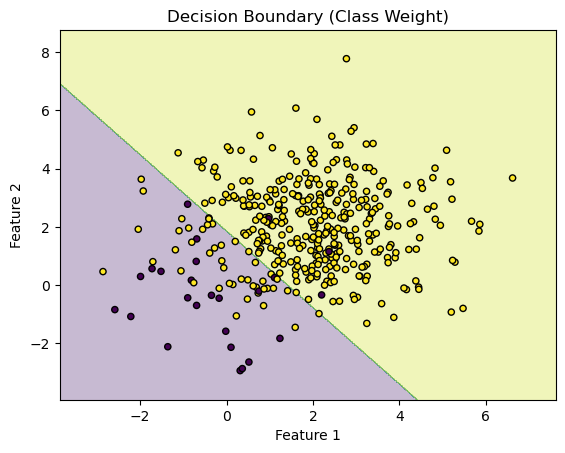

In [66]:
def plot_decision_boundary(X, y, model, title):
    step = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, step),
        np.arange(y_min, y_max, step)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=20)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


plot_decision_boundary(X, y, model, "Decision Boundary (Class Weight)")

| Method                      | Recall (0) | Precision (0) | F1 (0)   | Accuracy | AUC      |
| --------------------------- | ---------- | ------------- | -------- | -------- | -------- |
| Original                    | 0.71       | 0.71          | 0.71     | 0.97     | 0.93     |
| Undersampling               | 0.75       | 0.23          | 0.35     | 0.86     | 0.87     |
| Oversampling                | 0.75       | 0.23          | 0.35     | 0.86     | 0.87     |
| SMOTE                       | 0.75       | **0.27**      | **0.40** | **0.89** | 0.87     |
| Balanced RF                 | 0.75       | 0.20          | 0.32     | 0.84     | 0.78     |
| Class Weight (manual)       | **0.86**   | 0.19          | 0.31     | 0.78     | 0.93     |
| **Class Weight (balanced)** | **0.86**   | **0.26**      | **0.40** | **0.85** | **0.93** |


AUC same (0.925) → model already good at ranking
, Improvement came from:
- Better threshold positioning
- Better penalty balance

## 5.b) Custom Loss Function (Cost-Sensitive Learning Extension)

**Idea:**  
Instead of changing data (sampling) or weights (`class_weight`), we directly **modify the loss function** so the model learns according to the **real-world cost of errors**.

---

## Why Custom Loss?

In many real-world problems:

- **False Negative (FN)** is more critical than False Positive (FP)

Examples:
- Disease detection → missing a patient is dangerous  
- Fraud detection → missing fraud is costly  

> So we want the model to **penalize FN more than FP**

---

## How It Works

Normally, models minimize a standard loss (e.g., log loss):

$$
\mathcal{L} = - \left[ y \log(p) + (1 - y)\log(1 - p) \right]
$$

We modify it by adding **class-dependent weights**:

$$
\mathcal{L} = - \left[ w_1 \cdot y \log(p) + w_0 \cdot (1 - y)\log(1 - p) \right]
$$

Where:
- \( w_1 \) = weight for minority class (higher)  
- \( w_0 \) = weight for majority class  

---

## Key Effect

- False Negative → **heavily penalized**  
- Model shifts decision boundary to:
  - Catch more minority cases  
  - Increase recall  

---

## Algorithms That Support Custom Loss

Some models allow custom loss functions:

- Gradient Boosting (GB)  
- XGBoost  
- LightGBM  

> These models optimize loss iteratively → easy to customize

---

## Example (XGBoost - Concept)

Instead of writing full custom loss, you often use:

```python
scale_pos_weight = (number of negative samples / number of positive samples)

----
----

In [89]:
def custom_loss(preds, dtrain):
    labels = dtrain.get_label()
    
    preds_sigmoid = 1.0 / (1.0 + np.exp(-preds))
    
    false_negative_penalty = 10.0 
    false_positive_penalty = 1.0

    weights = np.where(labels == 0, false_negative_penalty, false_positive_penalty)
    
    grad = (preds_sigmoid - labels) * weights
    hess = preds_sigmoid * (1 - preds_sigmoid) * weights
    
    return grad, hess

In [90]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

In [91]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [92]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [93]:
params = {
    'max_depth': 3,
    'eta': 0.1,
    'verbosity': 0
}

In [94]:
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=50,
    obj=custom_loss
)

In [95]:
y_proba = bst.predict(dtest)
y_pred = (y_proba >= 0.5).astype(int)

In [96]:
print("Classification Report (Custom Loss):\n")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {auc:.4f}")

Classification Report (Custom Loss):

              precision    recall  f1-score   support

           0       0.31      0.71      0.43         7
           1       0.98      0.90      0.94       113

    accuracy                           0.89       120
   macro avg       0.65      0.81      0.69       120
weighted avg       0.94      0.89      0.91       120

ROC AUC Score: 0.8742


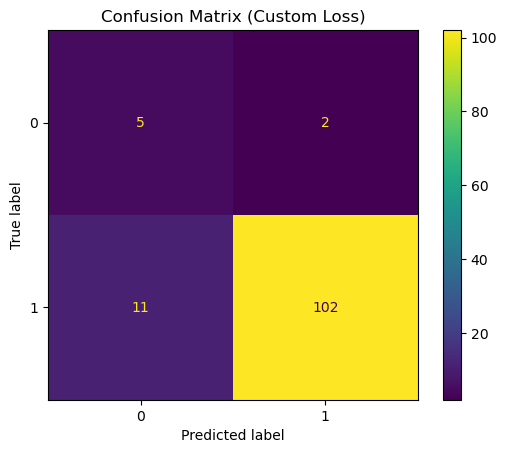

In [97]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Custom Loss)")
plt.show()

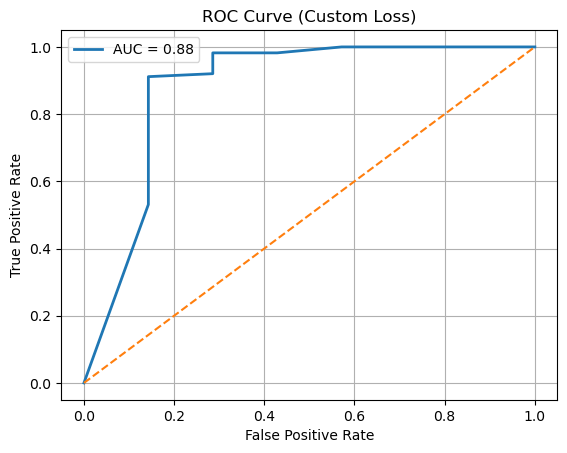

In [79]:
def plot_roc(y_test, y_proba):
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Custom Loss)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_roc(y_test, y_proba)

| Method          | Recall (0) | Precision (0) | F1 (0)   | Accuracy |
| --------------- | ---------- | ------------- | -------- | -------- |
| SMOTE           | 0.75       | 0.27          | 0.40     | 0.89     |
| **Custom Loss** | 0.71       | **0.31**      | **0.43** | 0.89     |


> we can also tune the custom loss function accrodingly

[SKlearn_Documentation_ImbalanceLearning](https://imbalanced-learn.org/stable/)